## Introduction

This project recreates a simplified version of the coding workflow from a biological aging paper. Using AI-generated synthetic protein data, I trained machine learning models to predict age and identify which proteins had the biggest impact on the predictions.

## Project Goal

The goal of this notebook is to:

1. Load synthetic proteomic data.

2. Use protein levels to predict chronological age.

3. Train and compare LASSO, SVR, and neural network models.

4. Calculate biological age gap.

5. Identify which proteins are most important for prediction.

6. Remove the top protein and observe how model performance changes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, r2_score
import os
print(os.getcwd())

/Users/Jaiden/Documents/Research/synthetic-proteomic-aging-clock/notebooks


## Data Description

The dataset contains 1,000 synthetic participants. Each participant has an age, sex, and multiple simulated protein measurements. Some proteins were designed to increase with age, some decrease with age, and others act mostly as noise.

This allows the model to learn protein-aging patterns and helps demonstrate how an aging clock is built.

In [2]:
df = pd.read_csv("../data/sound_life_all_olink.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(1274064, 26)
['sample.sampleKitGuid', 'specimen.specimenGuid', 'olink.batch_id', 'olink.plate_id', 'olink.panel', 'olink.assay', 'olink.assay_id', 'olink.uniprot_id', 'olink.norm_offset', 'olink.NPX_raw', 'olink.NPX_norm', 'olink.LOD_raw', 'olink.LOD_norm', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'sample.daysSinceFirstVisit']


/var/folders/mj/dnl0l32j66xfb5rfmcrpq4v40000gq/T/ipykernel_14155/131095236.py:1: DtypeWarning: Columns (0: olink.batch_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/sound_life_all_olink.csv")


,sample.sampleKitGuid,specimen.specimenGuid,olink.batch_id,olink.plate_id,olink.panel,olink.assay,olink.assay_id,olink.uniprot_id,olink.norm_offset,olink.NPX_raw,...,subject.birthYear,subject.ageAtFirstDraw,subject.ageGroup,subject.race,subject.ethnicity,subject.cmv,sample.visitName,sample.drawYear,sample.subjectAgeAtDraw,sample.daysSinceFirstVisit
0,KT00361,PL00361-01,20201752,20201752_SS200049_NEU_ONC,Neurology,TNFRSF1B,OID21145,P20333,0.0,0.1672,...,1988,31,Young Adult,Caucasian,Non-Hispanic origin,Positive,Flu Year 2 Day 7,2020,32,298
1,KT00361,PL00361-01,20201752,20201752_SS200049_NEU_ONC,Neurology,PAMR1,OID21153,Q6UXH9,0.0,0.3073,...,1988,31,Young Adult,Caucasian,Non-Hispanic origin,Positive,Flu Year 2 Day 7,2020,32,298
2,KT00361,PL00361-01,20201752,20201752_SS200049_NEU_ONC,Neurology,IL7R,OID21136,P16871,0.0,0.5881,...,1988,31,Young Adult,Caucasian,Non-Hispanic origin,Positive,Flu Year 2 Day 7,2020,32,298
3,KT00361,PL00361-01,20201752,20201752_SS200049_NEU_ONC,Neurology,CD177,OID21119,Q8N6Q3,0.0,NaN,...,1988,31,Young Adult,Caucasian,Non-Hispanic origin,Positive,Flu Year 2 Day 7,2020,32,298
4,KT00361,PL00361-01,20201752,20201752_SS200049_NEU_ONC,Neurology,PRTFDC1,OID20867,Q9NRG1,0.0,1.9377,...,1988,31,Young Adult,Caucasian,Non-Hispanic origin,Positive,Flu Year 2 Day 7,2020,32,298


In [3]:
df.shape

(1274064, 26)

In [4]:
df.columns

Index(['sample.sampleKitGuid', 'specimen.specimenGuid', 'olink.batch_id',
       'olink.plate_id', 'olink.panel', 'olink.assay', 'olink.assay_id',
       'olink.uniprot_id', 'olink.norm_offset', 'olink.NPX_raw',
       'olink.NPX_norm', 'olink.LOD_raw', 'olink.LOD_norm',
       'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex',
       'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup',
       'subject.race', 'subject.ethnicity', 'subject.cmv', 'sample.visitName',
       'sample.drawYear', 'sample.subjectAgeAtDraw',
       'sample.daysSinceFirstVisit'],
      dtype='str')

In [5]:
df.describe()

,olink.norm_offset,olink.NPX_raw,olink.NPX_norm,olink.LOD_raw,olink.LOD_norm,subject.birthYear,subject.ageAtFirstDraw,sample.drawYear,sample.subjectAgeAtDraw,sample.daysSinceFirstVisit
count,1.274064e+06,1.273541e+06,1.273541e+06,1.273541e+06,1.273541e+06,1.274064e+06,1.274064e+06,1.274064e+06,1.274064e+06,1.274064e+06
mean,1.307300e-01,3.386631e-01,4.694468e-01,-3.477129e+00,-3.346345e+00,1.974586e+03,4.526641e+01,2.020680e+03,4.609450e+01,2.767551e+02
std,5.783407e-01,1.028491e+00,1.070716e+00,2.748650e+00,2.759411e+00,1.438826e+01,1.449744e+01,7.119818e-01,1.451837e+01,2.090481e+02
min,-7.385000e+00,-1.435940e+01,-1.475400e+01,-1.259980e+01,-1.340680e+01,1.955000e+03,2.500000e+01,2.019000e+03,2.500000e+01,0.000000e+00
25%,-6.740000e-02,-1.400000e-01,-1.570000e-02,-5.565400e+00,-5.442400e+00,1.961000e+03,3.100000e+01,2.020000e+03,3.100000e+01,8.900000e+01
50%,0.000000e+00,2.841000e-01,3.920000e-01,-3.575300e+00,-3.433950e+00,1.965000e+03,5.500000e+01,2.021000e+03,5.500000e+01,2.620000e+02
75%,2.556000e-01,7.464000e-01,8.719000e-01,-1.099300e+00,-9.847500e-01,1.989000e+03,5.900000e+01,2.021000e+03,6.000000e+01,4.380000e+02
max,5.555350e+00,1.092780e+01,1.092780e+01,7.146600e+00,7.504300e+00,1.995000e+03,6.500000e+01,2.022000e+03,6.700000e+01,8.560000e+02


## Select Features and Target

The protein measurements were used as the input features (X), while chronological age was used as the target variable (y). The goal of the models is to learn the relationship between protein levels and age.

In [6]:
# Convert Olink data so each row is one sample
# and each column is one protein
real_data = df.pivot_table(
    index="sample.sampleKitGuid",
    columns="olink.assay",
    values="olink.NPX_norm",
    aggfunc="mean"
)

# Get age for each sample
age_data = (
    df.groupby("sample.sampleKitGuid")["sample.subjectAgeAtDraw"]
    .first()
)

real_data["age"] = age_data

print(real_data.shape)
real_data.head()

(867, 1473)


olink.assay,AARSD1,ABHD14B,ABL1,ACAA1,ACAN,ACE2,ACOX1,ACP5,ACP6,ACTA2,...,WWP2,XCL1,XG,XPNPEP2,XRCC4,YES1,YTHDF3,ZBTB16,ZBTB17,age
sample.sampleKitGuid,,,,,,,,,,,,,,,,,,,,,
KT00001,2.3968,-0.0024,0.4328,-2.1794,0.7174,-0.5271,-0.1398,0.0383,0.0499,-0.0875,...,-0.1201,1.0196,1.1625,-0.2974,0.3893,0.6681,1.0388,-0.2792,0.2367,32
KT00002,2.5518,-0.0353,-0.1173,-0.7889,0.3991,-0.2408,0.3677,0.4900,-0.2228,-0.6414,...,-0.0988,0.0997,0.1568,-1.1276,-0.0043,0.6109,0.5594,-0.1096,0.1002,28
KT00003,3.5256,0.8883,-0.2680,-1.3368,-0.1163,-0.7912,0.1919,0.1263,0.1536,-0.0456,...,0.0176,0.0662,0.5030,-0.0114,-0.4085,0.6453,-0.1745,0.1156,0.2255,30
KT00004,2.6322,0.7001,-0.1158,-0.9177,0.5898,-0.1305,0.4627,-0.0472,0.7599,0.0061,...,-0.2829,-0.0528,-0.1256,-0.5548,0.3063,0.7647,1.0288,0.0917,0.1285,30
KT00006,2.9550,-0.1049,0.0123,-0.6184,-0.0818,-0.9817,-0.5799,0.2396,-1.6798,-0.0956,...,-0.4276,1.4479,0.4039,-2.1362,0.0338,1.0936,1.0587,-0.0330,-0.1077,27


In [7]:
# Separate proteins and age
X = real_data.drop(columns=["age"])
y = real_data["age"]

# Remove proteins with more than 20% missing values
X = X.loc[:, X.isna().mean() <= 0.20]

# Fill remaining missing values with each protein's median
X = X.fillna(X.median())

print("Samples:", X.shape[0])
print("Proteins:", X.shape[1])
print("Missing values remaining:", X.isna().sum().sum())
print("Age range:", y.min(), "-", y.max())

Samples: 867
Proteins: 1463
Missing values remaining: 0
Age range: 25 - 67


## Model Training

Three machine learning models were trained to predict chronological age from protein levels:

- LASSO regression
- Support Vector Regression
- Neural Network

These models were chosen because they are similar to the model types compared in the paper. The data was split into training and testing sets so the models could be evaluated on unseen data.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Match each sample to its subject
sample_subject = (
    df.groupby("sample.sampleKitGuid")["subject.subjectGuid"]
    .first()
)

groups = sample_subject.loc[X.index]

# Split by subject so the same person cannot be in both sets
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)
print("People in both sets:",
      len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))

((693, 1463), (174, 1463))

## Train the LASSO Model

LASSO regression was used to predict age from protein levels. In addition to making predictions, LASSO helps identify which proteins contribute most to the model by assigning coefficients to each feature.

In [9]:
lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42)
)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("LASSO MAE:", lasso_mae)
print("LASSO R2:", lasso_r2)

LASSO MAE: 1.4634426856739844
LASSO R2: 0.9835874075075454


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.032e+02, tolerance: 1.452e+01
  model = cd_fast.enet_coordinate_descent(


## Train the Support Vector Regression (SVR) Model

Support Vector Regression is another machine learning algorithm for predicting age. Its performance can then be compared with the LASSO model.

In [10]:
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf")
)

svr_model.fit(X_train, y_train)

svr_pred = svr_model.predict(X_test)

svr_mae = mean_absolute_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

print("SVR MAE:", svr_mae)
print("SVR R2:", svr_r2)

SVR MAE: 8.046343033360216
SVR R2: 0.5819443799446613


## Train the Neural Network

A simple neural network was also trained to predict age. Neural networks can learn more complex relationships between proteins and age than linear models. The convergence warning indicates the neural network reached the maximum number of training iterations. The model still produced valid predictions for this demonstration.

In [11]:
nn_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(32, 16),
        max_iter=1000,
        random_state=42
    )
)

nn_model.fit(X_train, y_train)

nn_pred = nn_model.predict(X_test)

nn_mae = mean_absolute_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)

print("Neural Network MAE:", nn_mae)
print("Neural Network R2:", nn_r2)

Neural Network MAE: 6.788276423890803
Neural Network R2: 0.6658154306303234


In [12]:
elastic_model = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 0.95, 0.99],
        cv=5,
        random_state=42,
        max_iter=10000
    )
)

elastic_model.fit(X_train, y_train)

elastic_pred = elastic_model.predict(X_test)

elastic_mae = mean_absolute_error(y_test, elastic_pred)
elastic_r2 = r2_score(y_test, elastic_pred)

print("Elastic Net MAE:", elastic_mae)
print("Elastic Net R2:", elastic_r2)

Elastic Net MAE: 1.4443856210425445
Elastic Net R2: 0.9846674876577541




Because LASSO and Elastic Net performed well, I next tested a simplified BayesR approach. BayesR is a Bayesian regression method that uses a mixture of effect sizes, allowing some proteins to have little or no effect while others can have larger effects.

In [13]:
# Export the same train/test split for BayesR in R

X_train_bayes = X_train.copy()
X_test_bayes = X_test.copy()

X_train_bayes["age"] = y_train.values
X_test_bayes["age"] = y_test.values

X_train_bayes.to_csv("bayesr_train.csv", index=False)
X_test_bayes.to_csv("bayesr_test.csv", index=False)

print("BayesR files saved.")

BayesR files saved.


### BayesR Results

BayesR was run in R using the `hibayes` package on the same training and testing split used for the other models.

- MAE: 4.2442
- R²: 0.7949

BayesR produced results very similar to LASSO and Elastic Net, with a slightly lower MAE than LASSO.

## Compare Model Performance

The three models were compared using Mean Absolute Error (MAE) and R².

- MAE measures the average prediction error in years.
- R² measures how well the model explains the variation in age.

Lower MAE and higher R² indicate better model performance.

In [14]:
bayesr_mae = 4.244228
bayesr_r2 = 0.7948689

comparison = pd.DataFrame({
    "Model": ["LASSO", "SVR", "Neural Network", "Elastic Net", "BayesR"],
    "MAE": [lasso_mae, svr_mae, nn_mae, elastic_mae, bayesr_mae],
    "R2": [lasso_r2, svr_r2, nn_r2, elastic_r2, bayesr_r2]
})

comparison

,Model,MAE,R2
0,LASSO,1.463443,0.983587
1,SVR,8.046343,0.581944
2,Neural Network,6.788276,0.665815
3,Elastic Net,1.444386,0.984667
4,BayesR,4.244228,0.794869


## Interpretation

LASSO produced the best overall performance on this synthetic dataset, with the lowest prediction error and the highest R². SVR performed similarly, while the neural network achieved slightly lower accuracy.

In [15]:
results = pd.DataFrame({
    "real_age": y_test,
    "predicted_age": lasso_pred
})

results["biological_age_gap"] = results["predicted_age"] - results["real_age"]

results.head()

,real_age,predicted_age,biological_age_gap
sample.sampleKitGuid,,,
KT01430,30,28.971059,-1.028941
KT01540,61,61.152982,0.152982
KT00163,59,59.374265,0.374265
KT02593,60,61.607710,1.607710
KT01511,56,55.992994,-0.007006


## Predicted Age vs. Real Age

The scatter plot compares the predicted ages with the actual ages of the participants. Points closer to the diagonal line indicate more accurate predictions.

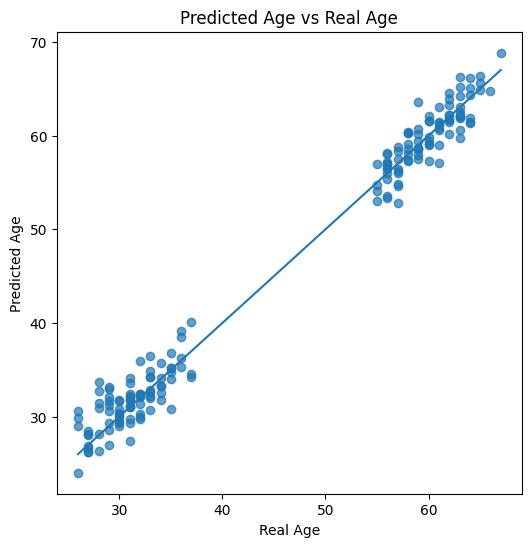

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(results["real_age"], results["predicted_age"], alpha=0.7)
plt.plot(
    [results["real_age"].min(), results["real_age"].max()],
    [results["real_age"].min(), results["real_age"].max()]
)
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted Age vs Real Age")
plt.show()

## Protein Importance

LASSO assigns coefficients to each protein, allowing the importance of each feature to be estimated. Proteins with larger coefficients have a greater influence on the age prediction model.

In [17]:
lasso = lasso_model.named_steps["lassocv"]

importance = pd.DataFrame({
    "protein": X.columns,
    "coefficient": lasso.coef_
})

importance["absolute_importance"] = importance["coefficient"].abs()

importance = importance.sort_values(
    "absolute_importance",
    ascending=False
)

importance

,protein,coefficient,absolute_importance
395,CXCL17,1.732580,1.732580
854,LTBP2,1.378387,1.378387
1192,SCARF2,0.945628,0.945628
1345,THBS2,-0.895988,0.895988
1159,RET,-0.876917,0.876917
...,...,...,...
192,CCL7,0.000000,0.000000
702,IL13,0.000000,0.000000
703,IL13RA1,-0.000000,0.000000
705,IL15RA,0.000000,0.000000


## Interpretation

GDF15 was identified as the most important protein in this synthetic dataset. This is expected because the synthetic data was designed so that GDF15 had a strong relationship with age.

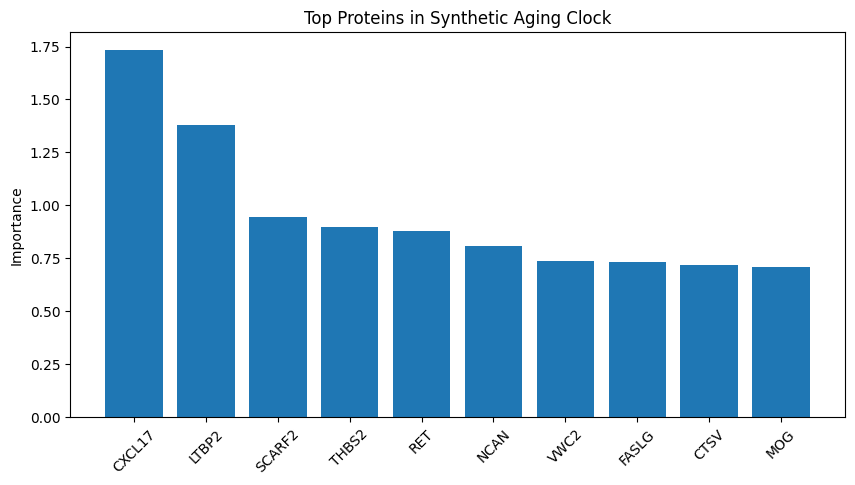

In [18]:
top_proteins = importance.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_proteins["protein"], top_proteins["absolute_importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Top Proteins in Synthetic Aging Clock")
plt.show()

## Protein Removal Experiment

To determine whether the top protein was truly important, I removed GDF15 and retrained the model. If model performance becomes worse after removing the protein, it suggests that the protein contributes significantly to age prediction.

In [19]:
top_protein = importance.iloc[0]["protein"]

print("Top protein:", top_protein)

X_removed = X.drop(columns=[top_protein])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_removed,
    y,
    test_size=0.2,
    random_state=42
)

removed_model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42)
)

removed_model.fit(X_train_r, y_train_r)

removed_pred = removed_model.predict(X_test_r)

removed_mae = mean_absolute_error(y_test_r, removed_pred)

print("Original LASSO MAE:", lasso_mae)
print("MAE after removing", top_protein, ":", removed_mae)

Top protein: CXCL17
Original LASSO MAE: 1.4634426856739844
MAE after removing CXCL17 : 1.4531025631215606


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.792e+02, tolerance: 1.452e+01
  model = cd_fast.enet_coordinate_descent(


## Interpretation

After removing GDF15, the prediction error increased from approximately 4.25 years to 4.69 years. This shows that the model relied heavily on GDF15 for predicting age in the synthetic dataset.

## Limitations

This project uses AI-generated synthetic data rather than real patient data. Therefore, the results should not be interpreted as biological discoveries. The purpose of this project is to understand and recreate the computational workflow used in biological aging research.

## Conclusion

This project successfully recreated a simplified version of a proteomic aging-clock workflow using AI-generated synthetic protein data. Multiple machine learning models were trained and compared, biological age gap was calculated, and protein importance was analyzed.

While the results should not be interpreted as biological discoveries, the project demonstrates how computational methods can be used to build and evaluate biological aging clocks.